## =============================
## Machine Learning Models for Metabolomics - MCI_to_AD Pipeline
## Author: Alejandro I. Trejo-Castro
## Last version 27.11.25
## Goal:
## 1. Make several experiments to test if metabolites are useful for diagnostics
# =============================

### Import Libraries

In [1]:
# Google Drive
from google.colab import drive

# Standard Data Science Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplots
import plotly.express as px

# Calculate spearman correlation
from scipy.stats import spearmanr

# Scikit learn modules for data preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

# Scikit learn modules for Model Selection
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Scikit learn modules for Model Evaluation & Improvement
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, precision_recall_curve
from sklearn.metrics import auc, roc_auc_score, roc_curve

# SHAP
import shap

# For saving in directory
import os

# Show no warnings
import warnings
warnings.filterwarnings('ignore')

# For compatibility with SHAP
!pip install "xgboost<3.0"


### Mount Google Drive

In [2]:
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


### Inspect data set

In [3]:
# Get train data
train_db = pd.read_csv("/content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/3. Results Databases/1. Exp MCI_to_AD/19.Train_final.csv")
train_db

,Classification,ADNI_MEM,ABETA42,ADAS11,APOE4,LPC.O.20.1.,ADNI_EF,LPI.20.4...SN2.,PTAU,GM3.D18.1.20.0.,...,PE.P.16.0.22.5...N6.,AC.18.1.,CE.22.0.,C8_0,C4_0,HEX2CER.D18.1.16.0.,PC.16.0_20.3...B.,L_ASPARTIC_ACID,PE.P.18.1.20.4...B.,GLYCERIC_ACID
0,1,-1.460,414.6,18.33,1,5.003080,0.944,8.345229,18.07,9.216260,...,9.554575,7.234227,6.885279,1.156539,-2.540703,9.906536,11.572560,3.210538,11.730752,1.032277
1,1,0.076,1258.0,7.00,0,5.546601,0.345,9.681017,18.23,8.535235,...,9.326451,6.740903,6.588239,1.097914,-2.014948,10.683437,11.207239,3.322519,11.100990,1.163698
2,1,-0.539,383.3,15.33,1,5.272267,-0.201,9.361557,58.65,9.240769,...,9.496325,7.353913,7.417421,2.186608,-1.411717,10.018529,11.510171,2.552625,11.492396,1.124745
3,1,-0.450,597.1,15.67,1,5.861030,-1.082,8.511587,30.25,9.019596,...,8.474707,7.688903,7.215782,0.028456,-2.465859,11.026746,11.005531,3.600520,10.676065,1.989226
4,1,-0.101,453.2,7.00,1,5.797304,1.310,8.661816,14.62,9.736203,...,9.276725,7.514567,7.600357,1.034082,-2.233556,10.753157,10.626215,4.325825,11.042674,2.944765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,1,-1.004,747.3,15.00,1,4.721328,-0.178,8.766605,32.40,8.739365,...,9.997603,7.163256,7.533335,0.474971,-1.084539,10.757908,10.689775,4.026632,10.481254,1.347547
126,1,-0.926,1127.0,17.00,1,4.399567,0.403,9.090200,51.87,7.980949,...,8.549122,7.197906,7.179665,0.533882,-1.304455,9.425909,11.491598,3.760423,12.167202,1.345964
127,0,1.554,2713.0,4.00,0,4.333484,0.526,8.873804,18.55,8.770004,...,8.510554,7.259411,6.534041,0.231936,-0.475579,9.305565,11.615782,3.166306,10.319074,0.980471
128,0,1.317,852.7,6.00,0,4.398944,0.961,8.875147,8.94,9.208476,...,8.823189,6.416010,7.097555,0.122633,-1.129260,9.584779,11.102671,4.129242,10.494116,1.291209


In [4]:
# Review Classification distribution on train data
train_db.value_counts("Classification")

,count
Classification,
1,76
0,54


In [5]:
# For plotting replace values for string
train_db['Classification'].replace(1, 'MCI-p', inplace=True)
train_db['Classification'].replace(0, 'MCI-s', inplace=True)


train_db['Classification'] = train_db['Classification'].astype(
    pd.CategoricalDtype(categories=['MCI-s', 'MCI-p'], ordered=True)
)

train_db.value_counts("Classification")


,count
Classification,
MCI-p,76
MCI-s,54


In [6]:
# Review colum names
train_db.columns

Index(['Classification', 'ADNI_MEM', 'ABETA42', 'ADAS11', 'APOE4',
       'LPC.O.20.1.', 'ADNI_EF', 'LPI.20.4...SN2.', 'PTAU', 'GM3.D18.1.20.0.',
       'C7_0', 'PE.P.16.0.22.5...N6.', 'AC.18.1.', 'CE.22.0.', 'C8_0', 'C4_0',
       'HEX2CER.D18.1.16.0.', 'PC.16.0_20.3...B.', 'L_ASPARTIC_ACID',
       'PE.P.18.1.20.4...B.', 'GLYCERIC_ACID'],
      dtype='object')

In [7]:
# First number refer to rows and the second to columns
train_db.shape

(130, 21)

In [8]:
# Review properties of dataset
train_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Classification        130 non-null    category
 1   ADNI_MEM              130 non-null    float64 
 2   ABETA42               130 non-null    float64 
 3   ADAS11                130 non-null    float64 
 4   APOE4                 130 non-null    int64   
 5   LPC.O.20.1.           130 non-null    float64 
 6   ADNI_EF               130 non-null    float64 
 7   LPI.20.4...SN2.       130 non-null    float64 
 8   PTAU                  130 non-null    float64 
 9   GM3.D18.1.20.0.       130 non-null    float64 
 10  C7_0                  130 non-null    float64 
 11  PE.P.16.0.22.5...N6.  130 non-null    float64 
 12  AC.18.1.              130 non-null    float64 
 13  CE.22.0.              130 non-null    float64 
 14  C8_0                  130 non-null    float64 
 15  C4_0  

### Descriptive Statistics: Measures of Central Tendency

In [9]:
# Statistics in General
np.round(train_db.describe(),2)

,ADNI_MEM,ABETA42,ADAS11,APOE4,LPC.O.20.1.,ADNI_EF,LPI.20.4...SN2.,PTAU,GM3.D18.1.20.0.,C7_0,PE.P.16.0.22.5...N6.,AC.18.1.,CE.22.0.,C8_0,C4_0,HEX2CER.D18.1.16.0.,PC.16.0_20.3...B.,L_ASPARTIC_ACID,PE.P.18.1.20.4...B.,GLYCERIC_ACID
count,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00,130.00
mean,-0.02,982.42,11.28,0.55,5.18,-0.02,8.54,30.17,8.94,-2.51,8.76,7.25,6.83,0.36,-1.12,10.09,11.06,3.44,10.77,1.62
std,0.72,630.48,4.95,0.50,0.56,0.77,0.51,13.05,0.61,0.57,0.71,0.44,0.55,0.67,0.95,0.52,0.55,0.52,0.71,0.55
min,-1.80,267.20,3.00,0.00,3.74,-2.01,7.43,8.94,7.44,-4.68,6.92,6.20,5.31,-1.30,-4.48,8.57,9.63,-0.13,8.57,0.23
25%,-0.50,592.95,8.00,0.00,4.77,-0.50,8.20,19.75,8.54,-2.76,8.29,6.95,6.48,-0.03,-1.60,9.71,10.65,3.21,10.31,1.28
50%,-0.01,727.50,10.84,1.00,5.16,-0.12,8.48,27.90,8.95,-2.51,8.77,7.30,6.85,0.33,-1.11,10.14,11.07,3.45,10.79,1.56
75%,0.49,1128.50,13.33,1.00,5.65,0.50,8.87,38.63,9.31,-2.16,9.31,7.52,7.20,0.71,-0.61,10.46,11.46,3.76,11.27,1.87
max,1.85,3331.00,26.00,1.00,6.46,1.94,10.01,62.48,10.67,-0.99,10.12,8.27,7.94,2.59,1.93,11.48,12.50,4.57,12.81,3.17


In [10]:
# Statistics for MCI-s
MCIs = train_db[train_db['Classification']=='MCI-s']
np.round(MCIs.describe(),2)

,ADNI_MEM,ABETA42,ADAS11,APOE4,LPC.O.20.1.,ADNI_EF,LPI.20.4...SN2.,PTAU,GM3.D18.1.20.0.,C7_0,PE.P.16.0.22.5...N6.,AC.18.1.,CE.22.0.,C8_0,C4_0,HEX2CER.D18.1.16.0.,PC.16.0_20.3...B.,L_ASPARTIC_ACID,PE.P.18.1.20.4...B.,GLYCERIC_ACID
count,54.00,54.00,54.00,54.00,54.00,54.00,54.00,54.00,54.00,54.00,54.00,54.00,54.00,54.00,54.00,54.00,54.00,54.00,54.00,54.00
mean,0.52,1363.61,8.01,0.30,4.93,0.39,8.37,24.94,8.70,-2.32,8.47,7.07,6.63,0.58,-0.82,9.91,10.90,3.27,10.52,1.45
std,0.55,723.79,2.97,0.46,0.47,0.71,0.42,11.80,0.58,0.43,0.71,0.42,0.60,0.60,0.79,0.54,0.48,0.60,0.59,0.51
min,-0.55,396.60,3.00,0.00,3.87,-1.06,7.43,8.94,7.44,-3.21,6.92,6.21,5.31,-0.38,-3.03,8.57,10.04,-0.13,9.39,0.23
25%,0.10,833.88,5.33,0.00,4.51,-0.15,8.06,17.38,8.34,-2.62,7.97,6.76,6.32,0.16,-1.25,9.59,10.48,3.05,10.08,1.10
50%,0.55,1113.00,8.00,0.00,4.90,0.32,8.38,20.83,8.81,-2.28,8.50,7.10,6.63,0.54,-0.73,9.96,10.82,3.35,10.50,1.52
75%,0.84,1858.50,10.75,1.00,5.33,0.88,8.70,31.96,9.08,-2.08,8.83,7.41,7.01,0.93,-0.34,10.31,11.34,3.56,10.88,1.70
max,1.85,3331.00,13.00,1.00,5.86,1.94,9.34,57.71,10.00,-0.99,9.82,7.95,7.94,2.59,1.93,10.92,11.87,4.13,12.08,2.91


In [11]:
# Statistics for MCI-p
MCIp = train_db[train_db['Classification']=='MCI-p']
np.round(MCIp.describe(),2)

,ADNI_MEM,ABETA42,ADAS11,APOE4,LPC.O.20.1.,ADNI_EF,LPI.20.4...SN2.,PTAU,GM3.D18.1.20.0.,C7_0,PE.P.16.0.22.5...N6.,AC.18.1.,CE.22.0.,C8_0,C4_0,HEX2CER.D18.1.16.0.,PC.16.0_20.3...B.,L_ASPARTIC_ACID,PE.P.18.1.20.4...B.,GLYCERIC_ACID
count,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00
mean,-0.41,711.57,13.61,0.72,5.36,-0.32,8.67,33.89,9.12,-2.64,8.96,7.38,6.97,0.20,-1.33,10.22,11.17,3.55,10.95,1.75
std,0.57,366.79,4.77,0.45,0.56,0.68,0.54,12.68,0.57,0.62,0.64,0.41,0.46,0.67,1.00,0.47,0.56,0.43,0.74,0.55
min,-1.80,267.20,5.00,0.00,3.74,-2.01,7.54,11.53,7.98,-4.68,7.08,6.20,5.86,-1.30,-4.48,9.12,9.63,2.46,8.57,0.56
25%,-0.88,541.40,10.00,0.00,5.00,-0.79,8.30,23.74,8.68,-2.95,8.51,7.16,6.68,-0.22,-1.81,9.85,10.85,3.32,10.52,1.41
50%,-0.34,625.40,12.67,1.00,5.34,-0.30,8.60,32.17,9.08,-2.60,8.96,7.36,6.99,0.25,-1.37,10.27,11.22,3.58,10.97,1.67
75%,-0.02,749.25,17.08,1.00,5.78,0.12,9.03,41.22,9.53,-2.30,9.48,7.69,7.33,0.49,-0.86,10.53,11.53,3.81,11.38,2.06
max,0.71,2387.00,26.00,1.00,6.46,1.31,10.01,62.48,10.67,-1.26,10.12,8.27,7.93,2.19,1.07,11.48,12.50,4.57,12.81,3.17


### Dictionary for Feature and Description

In [12]:
# Feature and Description
names = pd.read_csv("/content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/3. Results Databases/1. Exp MCI_to_AD/Names_Final_Features.csv")
names

,Feature,Description
0,ADAS11,Alzheimer's Disease Assessment Scale 11 items ...
1,ADNI_MEM,ADNI composite score for memory
2,ADNI_EF,ADNI composite score for executive functioning
3,ADNI_LAN,ADNI composite score for language
4,APOE4,APOE4 carrier status
5,ABETA42,CSF AB42
6,PTAU,CSF p-Tau
7,HEX2CER.D18.1.16.0.,Hex2Cer(d18:1/16:0). Lipid metabolite
8,HEX2CER.D18.1.20.0.,Hex2Cer(d18:1/20:0). Lipid metabolite
9,GM3.D18.1.20.0.,GM3(d18:1/20:0). Lipid metabolite


In [13]:
feature_dict = pd.Series(names['Description'].values, index=names['Feature']).to_dict()

### Boxplots

In [14]:
for column in train_db.select_dtypes(include='float64'):
    fig = px.box(
        data_frame=train_db,
        x="Classification",
        y=column,
        points="all",
        color="Classification",
        labels={"y": column},
        category_orders={"Classification": ["MCI-s", "MCI-p"]}
    )
    fig.show()


### Spearman Correlation

#### Spearman Correlation Matrix

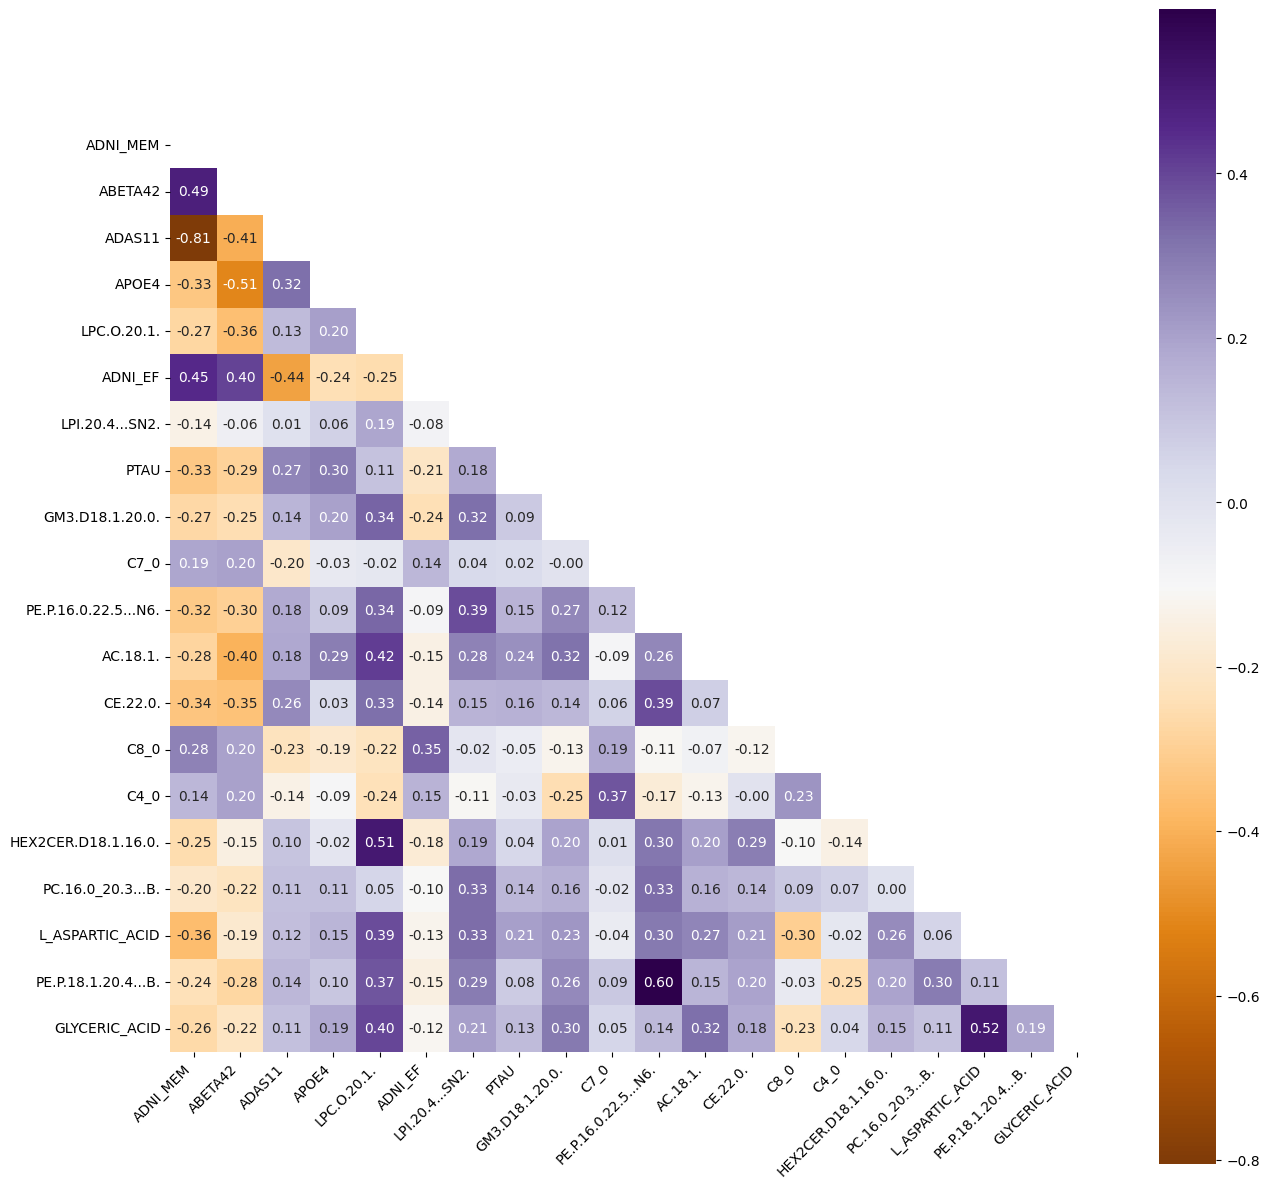

In [15]:
matrix = train_db.drop('Classification', axis=1)
corrmat = matrix.corr(method='spearman')
# Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(corrmat, dtype=bool))

plt.figure(figsize=(15, 15))
ax = sns.heatmap(
    corrmat,
    annot=True,
    square=True,
    cmap="PuOr",
    fmt=".2f",
    mask=mask # Apply the mask here
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.show()

In [16]:
# Saving Plot
ruta = "/content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/spearman_matrix.tif"
os.makedirs(os.path.dirname(ruta), exist_ok=True)

plt.close('all')  # clear open figures

# Calculate correlation matrix
matrix = train_db.drop('Classification', axis=1)
corrmat = matrix.corr(method='spearman')

# Create figure and axes
fig, ax = plt.subplots(figsize=(15, 15))

# Create mask to hide upper triangle
mask = np.triu(np.ones_like(corrmat, dtype=bool))

# Heatmap
sns.heatmap(
    corrmat,
    annot=True,
    square=True,
    cmap="PuOr",
    fmt=".2f",
    mask=mask,
    ax=ax  # Use ax
)

# Text and Style Adjustment
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.grid(True, linestyle='--', alpha=0.75)
ax.set_title("Spearman Correlation Matrix", fontsize=14, fontweight='bold', pad=16)

# Saving figure
fig.savefig(
    ruta,
    dpi=300,
    format="tiff",
    bbox_inches="tight"
)

plt.close()  # Close figure

print("Gráfico guardado en:", ruta)


Gráfico guardado en: /content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/spearman_matrix.tif


#### Pair of features analysis

##### CSF AB42 and Butyric Acid

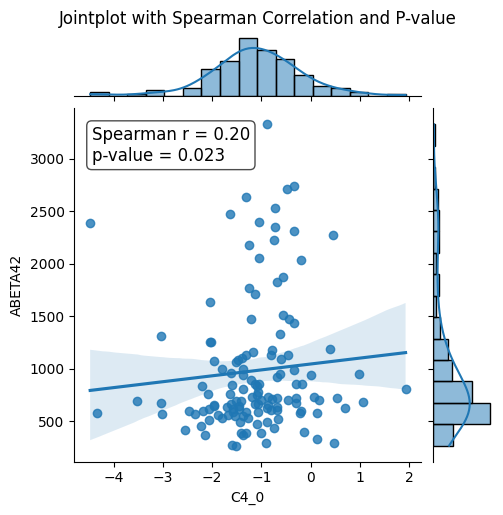

In [17]:
# Create the jointplot

# Use 'kind='reg'' to show a regression line and confidence interval
j = sns.jointplot(x='C4_0', y='ABETA42', data=train_db, kind='reg', height=5)

# Calculate Spearman correlation and p-value
r, p = spearmanr(train_db['C4_0'], train_db['ABETA42'])

# Annotate the plot with the Spearman correlation and p-value
# Use j.ax_joint to access the main scatter plot axes for annotation
j.ax_joint.annotate(f'Spearman r = {r:.2f}\np-value = {p:.3f}',
                    xy=(0.05, 0.95), xycoords='axes fraction',
                    fontsize=12, horizontalalignment='left', verticalalignment='top',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1, alpha=0.7))

plt.suptitle('Jointplot with Spearman Correlation and P-value', y=1.02)
plt.show()

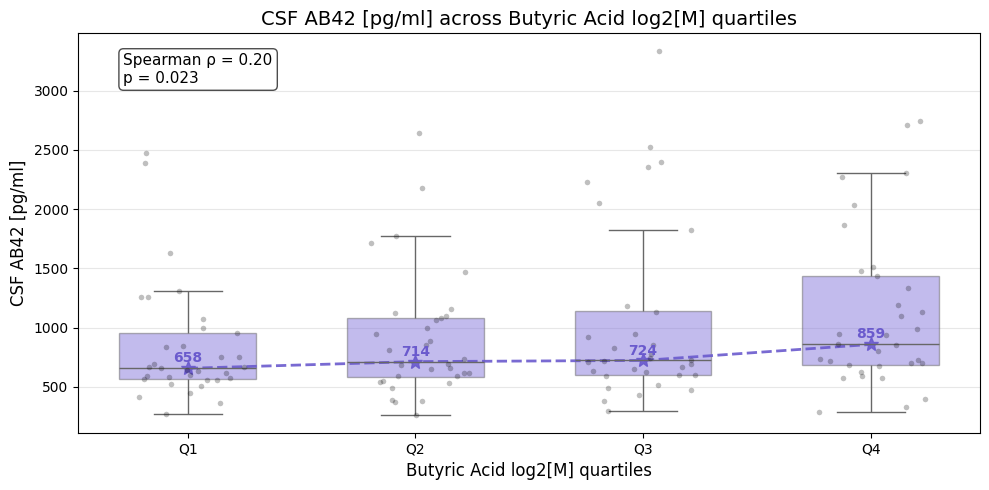

In [18]:
# Calculate Spearman correlation and p-value
rho, pval = spearmanr(train_db['C4_0'], train_db['ABETA42'])

# Transform feature to quartiles
train_db['C4_q'] = pd.qcut(train_db['C4_0'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

plt.figure(figsize=(10,5))

# Boxplot
sns.boxplot(x='C4_q', y='ABETA42', data=train_db, showfliers=False,
            width=0.6, boxprops=dict(alpha=0.5), color='mediumslateblue')

# Stripplot
sns.stripplot(x='C4_q', y='ABETA42', data=train_db, jitter=0.25,
              alpha=0.25, color='black', size=4)

# Medians and lineplot
medians = train_db.groupby('C4_q')['ABETA42'].median().values
plt.plot(range(4), medians, marker='*', linestyle='--', linewidth=2, alpha=0.9, color='slateblue',
         markersize=10)

# Add labels up to the median
for i, median in enumerate(medians):
    plt.text(i, median + 50, f'{median:.0f}',
             ha='center', fontsize=10, color='slateblue', fontweight='bold')

# Spearman annotation
plt.text(0.05, 0.95,
         f'Spearman ρ = {rho:.2f}\np = {pval:.3f}',
         transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.title('CSF AB42 [pg/ml] across Butyric Acid log2[M] quartiles', fontsize=14)
plt.xlabel('Butyric Acid log2[M] quartiles', fontsize=12)
plt.ylabel('CSF AB42 [pg/ml]', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Saving plot

ruta = "/content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/AB42vsC4.tif"
os.makedirs(os.path.dirname(ruta), exist_ok=True)

rho, pval = spearmanr(train_db['C4_0'], train_db['ABETA42'])
train_db['C4_q'] = pd.qcut(train_db['C4_0'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

plt.figure(figsize=(10,5))


sns.boxplot(x='C4_q', y='ABETA42', data=train_db, showfliers=False,
            width=0.6, boxprops=dict(alpha=0.5), color='mediumslateblue')

sns.stripplot(x='C4_q', y='ABETA42', data=train_db, jitter=0.25,
              alpha=0.25, color='black', size=4)

medians = train_db.groupby('C4_q')['ABETA42'].median().values
plt.plot(range(4), medians, marker='*', linestyle='--', linewidth=2, alpha=0.9, color='slateblue',
         markersize=10)

for i, median in enumerate(medians):
    plt.text(i, median + 50, f'{median:.0f}',
             ha='center', fontsize=10, color='slateblue', fontweight='bold')

plt.text(0.05, 0.95,
         f'Spearman ρ = {rho:.2f}\np = {pval:.3f}',
         transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.title('CSF AB42 [pg/ml] across Butyric Acid log2[M] quartiles', fontsize=14)
plt.xlabel('Butyric Acid log2[M] quartiles', fontsize=12)
plt.ylabel('CSF AB42 [pg/ml]', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(
    ruta,
    dpi=300,
    format="tiff",
    bbox_inches="tight"
)

plt.close()

print("Gráfico guardado en:", ruta)

Gráfico guardado en: /content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/AB42vsC4.tif


##### CSF AB42 and AC.18.1.

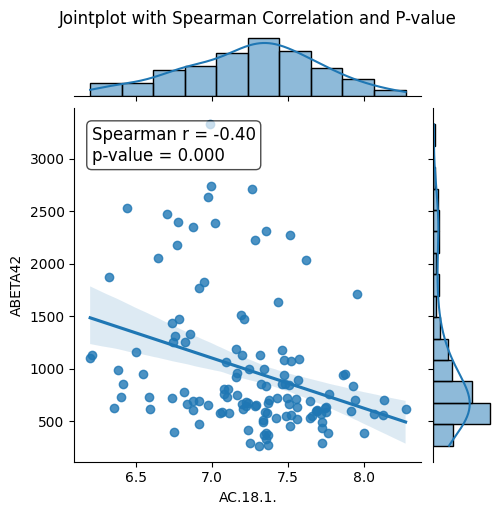

In [20]:
# Use 'kind='reg'' to show a regression line and confidence interval
j = sns.jointplot(x='AC.18.1.', y='ABETA42', data=train_db, kind='reg', height=5)

# Calculate Spearman correlation and p-value
r, p = spearmanr(train_db['AC.18.1.'], train_db['ABETA42'])

# Annotate the plot with the Spearman correlation and p-value
# Use j.ax_joint to access the main scatter plot axes for annotation
j.ax_joint.annotate(f'Spearman r = {r:.2f}\np-value = {p:.3f}',
                    xy=(0.05, 0.95), xycoords='axes fraction',
                    fontsize=12, horizontalalignment='left', verticalalignment='top',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1, alpha=0.7))

plt.suptitle('Jointplot with Spearman Correlation and P-value', y=1.02) # Add a main title
plt.show()

##### CSF AB42 and Caprylic Acid

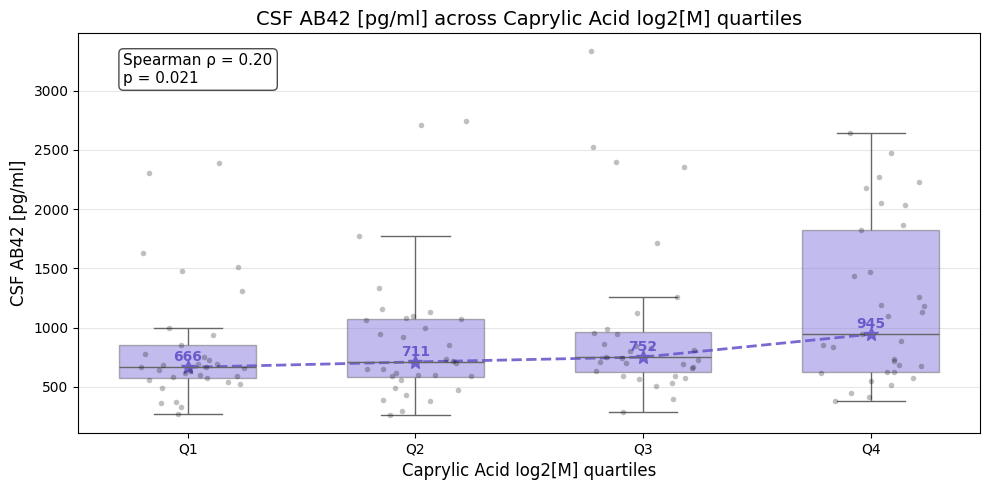

In [21]:
rho, pval = spearmanr(train_db['C8_0'], train_db['ABETA42'])


train_db['C8_q'] = pd.qcut(train_db['C8_0'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

plt.figure(figsize=(10,5))

sns.boxplot(x='C8_q', y='ABETA42', data=train_db, showfliers=False,
            width=0.6, boxprops=dict(alpha=0.5), color='mediumslateblue')

sns.stripplot(x='C8_q', y='ABETA42', data=train_db, jitter=0.25,
              alpha=0.25, color='black', size=4)

medians = train_db.groupby('C8_q')['ABETA42'].median().values
plt.plot(range(4), medians, marker='*', linestyle='--', linewidth=2, alpha=0.9, color='slateblue',
         markersize=10)

for i, median in enumerate(medians):
    plt.text(i, median + 50, f'{median:.0f}',
             ha='center', fontsize=10, color='slateblue', fontweight='bold')

plt.text(0.05, 0.95,
         f'Spearman ρ = {rho:.2f}\np = {pval:.3f}',
         transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.title('CSF AB42 [pg/ml] across Caprylic Acid log2[M] quartiles', fontsize=14)
plt.xlabel('Caprylic Acid log2[M] quartiles', fontsize=12)
plt.ylabel('CSF AB42 [pg/ml]', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Saving Plot
ruta = "/content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/AB42vsC8.tif"
os.makedirs(os.path.dirname(ruta), exist_ok=True)

rho, pval = spearmanr(train_db['C8_0'], train_db['ABETA42'])
train_db['C8_q'] = pd.qcut(train_db['C8_0'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

plt.figure(figsize=(10,5))

sns.boxplot(x='C8_q', y='ABETA42', data=train_db, showfliers=False,
            width=0.6, boxprops=dict(alpha=0.5), color='mediumslateblue')

sns.stripplot(x='C8_q', y='ABETA42', data=train_db, jitter=0.25,
              alpha=0.25, color='black', size=4)

medians = train_db.groupby('C8_q')['ABETA42'].median().values
plt.plot(range(4), medians, marker='*', linestyle='--', linewidth=2, alpha=0.9, color='slateblue',
         markersize=10)

for i, median in enumerate(medians):
    plt.text(i, median + 50, f'{median:.0f}',
             ha='center', fontsize=10, color='slateblue', fontweight='bold')

plt.text(0.05, 0.95,
         f'Spearman ρ = {rho:.2f}\np = {pval:.3f}',
         transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.title('CSF AB42 [pg/ml] across Caprylic Acid log2[M] quartiles', fontsize=14)
plt.xlabel('Caprylic Acid log2[M] quartiles', fontsize=12)
plt.ylabel('CSF AB42 [pg/ml]', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(
    ruta,
    dpi=300,
    format="tiff",
    bbox_inches="tight"
)

plt.close()

print("Gráfico guardado en:", ruta)

Gráfico guardado en: /content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/AB42vsC8.tif


### Sandardization

In [23]:
# Separation in X_train and y_train
X_train = train_db.drop(["Classification","C4_q","C8_q"],axis=1)
X_train.head()

,ADNI_MEM,ABETA42,ADAS11,APOE4,LPC.O.20.1.,ADNI_EF,LPI.20.4...SN2.,PTAU,GM3.D18.1.20.0.,C7_0,PE.P.16.0.22.5...N6.,AC.18.1.,CE.22.0.,C8_0,C4_0,HEX2CER.D18.1.16.0.,PC.16.0_20.3...B.,L_ASPARTIC_ACID,PE.P.18.1.20.4...B.,GLYCERIC_ACID
0,-1.460,414.6,18.33,1,5.003080,0.944,8.345229,18.07,9.216260,-4.681477,9.554575,7.234227,6.885279,1.156539,-2.540703,9.906536,11.572560,3.210538,11.730752,1.032277
1,0.076,1258.0,7.00,0,5.546601,0.345,9.681017,18.23,8.535235,-3.497054,9.326451,6.740903,6.588239,1.097914,-2.014948,10.683437,11.207239,3.322519,11.100990,1.163698
2,-0.539,383.3,15.33,1,5.272267,-0.201,9.361557,58.65,9.240769,-3.258853,9.496325,7.353913,7.417421,2.186608,-1.411717,10.018529,11.510171,2.552625,11.492396,1.124745
3,-0.450,597.1,15.67,1,5.861030,-1.082,8.511587,30.25,9.019596,-3.202824,8.474707,7.688903,7.215782,0.028456,-2.465859,11.026746,11.005531,3.600520,10.676065,1.989226
4,-0.101,453.2,7.00,1,5.797304,1.310,8.661816,14.62,9.736203,-2.037118,9.276725,7.514567,7.600357,1.034082,-2.233556,10.753157,10.626215,4.325825,11.042674,2.944765


In [24]:
# Binary target (0 and 1)
y_train= train_db.Classification
y_train = y_train.replace({'MCI-s': 0, 'MCI-p': 1})
y_train.head()

,Classification
0,1
1,1
2,1
3,1
4,1


In [25]:
y_train.value_counts()

,count
Classification,
1,76
0,54


In [26]:
# Get test data
test_db = pd.read_csv("/content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/3. Results Databases/1. Exp MCI_to_AD/20.Test_final.csv")
test_db.head()

,Classification,ADNI_MEM,ABETA42,ADAS11,APOE4,LPC.O.20.1.,ADNI_EF,LPI.20.4...SN2.,PTAU,GM3.D18.1.20.0.,...,PE.P.16.0.22.5...N6.,AC.18.1.,CE.22.0.,C8_0,C4_0,HEX2CER.D18.1.16.0.,PC.16.0_20.3...B.,L_ASPARTIC_ACID,PE.P.18.1.20.4...B.,GLYCERIC_ACID
0,1,-1.155,792.7,19.00,0,5.618178,-0.868,9.058334,65.40,8.882707,...,9.101166,7.080074,6.699473,0.357518,-3.151644,9.090331,10.699536,3.571119,11.242632,1.890563
1,1,-0.697,282.9,10.33,0,4.979131,0.038,8.201222,20.29,9.893676,...,9.074231,7.538255,6.735160,0.946095,-1.751115,10.212317,11.332821,3.233031,10.979527,2.326235
2,1,-0.511,683.1,14.33,1,5.842681,0.229,9.794848,48.14,9.479348,...,8.702468,7.749296,6.960462,0.414590,-1.333607,10.415838,11.091746,3.718066,11.148539,2.084299
3,1,0.631,1338.0,12.33,0,5.714901,0.410,9.481283,22.91,10.070812,...,8.328543,8.628332,6.643919,4.601019,1.385762,9.929874,10.552215,4.551122,10.374418,2.359119
4,1,-0.767,556.7,13.67,1,5.763520,0.204,8.931726,29.26,8.839761,...,9.072683,7.646721,7.110802,-0.517786,-1.058392,10.778520,11.102861,3.450736,11.279021,1.757203


In [27]:
# Get the proportion in the Classification feature
test_db.value_counts("Classification")

,count
Classification,
1,19
0,13


In [28]:
# Obtain X_test and y_test
X_test = test_db.drop("Classification",axis=1)
y_test= test_db.Classification

print("Shape X_train dataset: ", X_train.shape)
print("Shape y_train dataset: ", y_train.shape)
print("Shape X_test dataset: ", X_test.shape)
print("Shape y_test dataset: ", y_test.shape)

Shape X_train dataset:  (130, 20)
Shape y_train dataset:  (130,)
Shape X_test dataset:  (32, 20)
Shape y_test dataset:  (32,)


In [29]:
# Standardization to z-values
sc_X = StandardScaler()

X_train2 = pd.DataFrame(sc_X.fit_transform(X_train))
X_train2.columns = X_train.columns.values
X_train2.index = X_train.index.values
X_train = X_train2

X_test2 = pd.DataFrame(sc_X.transform(X_test))
X_test2.columns = X_test.columns.values
X_test2.index = X_test.index.values
X_test = X_test2

In [30]:
# Rename columns for a better description
X_train.rename(columns=feature_dict, inplace=True)
X_test.rename(columns=feature_dict, inplace=True)

print("X_train columns:", X_train.columns)
print("-----------------------------------")
print("-----------------------------------")
print("X_test columnsX_test:", X_test.columns)

X_train columns: Index(['ADNI composite score for memory', 'CSF AB42',
       'Alzheimer's Disease Assessment Scale 11 items score',
       'APOE4 carrier status', 'LPC(O-20:1). Lipid metabolite',
       'ADNI composite score for executive functioning ',
       'LPI(20:4) [sn2]. Lipid metabolite', 'CSF p-Tau',
       'GM3(d18:1/20:0). Lipid metabolite', 'Heptanoic acid',
       'PE(P-16:0/22:5) (n6). Lipid metabolite', 'AC(18:1). Lipid metabolite',
       'CE(22:0). Lipid metabolite', 'Caprylic acid', 'Butyric acid',
       'Hex2Cer(d18:1/16:0). Lipid metabolite',
       'PC(16:0_20:3) (b). Lipid metabolite', 'L-Aspartic acid',
       'PE(P-18:1/20:4) (b). Lipid metabolite', 'Glyceric acid'],
      dtype='object')
-----------------------------------
-----------------------------------
X_test columnsX_test: Index(['ADNI composite score for memory', 'CSF AB42',
       'Alzheimer's Disease Assessment Scale 11 items score',
       'APOE4 carrier status', 'LPC(O-20:1). Lipid metabolite',
  

In [31]:
# Review z-values dataset for X_train
X_train.head()

,ADNI composite score for memory,CSF AB42,Alzheimer's Disease Assessment Scale 11 items score,APOE4 carrier status,LPC(O-20:1). Lipid metabolite,ADNI composite score for executive functioning,LPI(20:4) [sn2]. Lipid metabolite,CSF p-Tau,GM3(d18:1/20:0). Lipid metabolite,Heptanoic acid,PE(P-16:0/22:5) (n6). Lipid metabolite,AC(18:1). Lipid metabolite,CE(22:0). Lipid metabolite,Caprylic acid,Butyric acid,Hex2Cer(d18:1/16:0). Lipid metabolite,PC(16:0_20:3) (b). Lipid metabolite,L-Aspartic acid,PE(P-18:1/20:4) (b). Lipid metabolite,Glyceric acid
0,-1.992547,-0.904097,1.428974,0.911584,-0.315155,1.251211,-0.389211,-0.931226,0.449375,-3.824846,1.125780,-0.035076,0.095862,1.198059,-1.506930,-0.351766,0.944450,-0.430831,1.350684,-1.072305
1,0.138848,0.438794,-0.867368,-1.096991,0.654123,0.474794,2.215264,-0.918916,-0.674367,-1.739972,0.803506,-1.168031,-0.447339,1.110226,-0.949546,1.148643,0.274860,-0.216259,0.461894,-0.833430
2,-0.714543,-0.953934,0.820939,0.911584,0.164895,-0.232925,1.592392,2.191032,0.489816,-1.320679,1.043489,0.239793,1.068997,2.741322,-0.310025,-0.135477,0.830098,-1.691491,1.014289,-0.904233
3,-0.591044,-0.613514,0.889850,0.911584,1.214854,-1.374868,-0.064851,0.005913,0.124864,-1.222055,-0.399767,1.009121,0.700258,-0.492050,-1.427584,1.811667,-0.094845,0.316431,-0.137809,0.667079
4,-0.106762,-0.842637,-0.867368,0.911584,1.101210,1.725617,0.228060,-1.196672,1.307319,0.829874,0.733257,0.608745,1.403535,1.014592,-1.181305,1.283292,-0.790085,1.706226,0.379591,2.403899


### Logistic Regression

#### Param Grid

In [32]:
param_grid = [
    # Solvers with l2/none penalty
    {'solver': ['lbfgs', 'newton-cg', 'sag'],
     'penalty': ['l2', 'none'],
     'C': [100, 10, 1.0, 0.1, 0.01],
     'max_iter': [1000, 2000]},
    # liblinear (binary), l1 or l2
    {'solver': ['liblinear'],
     'penalty': ['l1', 'l2'],
     'C': [100, 10, 1.0, 0.1, 0.01],
     'max_iter': [1000, 2000]},
    # saga: l1, l2, elasticnet (requires l1_ratio)
    {'solver': ['saga'],
     'penalty': ['l1', 'l2'],
     'C': [100, 10, 1.0, 0.1, 0.01],
     'max_iter': [1000, 2000]},
    {'solver': ['saga'],
     'penalty': ['elasticnet'],
     'l1_ratio': [0.2, 0.5, 0.8],
     'C': [1.0, 0.1],
     'max_iter': [1000, 2000]},
]

# StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
grid_search = GridSearchCV(LogisticRegression(random_state=0, class_weight='balanced'), param_grid = param_grid, cv=skf,
                           scoring='f1_weighted',n_jobs=-1, refit=True)


#### All Features Model

In [33]:
grid_search.fit(X_train,y_train)
print ("Mean cross-validated score of the best_estimator: {}".format (grid_search.best_score_))
print ("best parameters: {}".format (grid_search.best_params_))
print ("best estimator: {}".format (grid_search.best_estimator_))

best = grid_search.best_estimator_
y1 = best.predict(X_test)

Mean cross-validated score of the best_estimator: 0.8463403263403263
best parameters: {'C': 1.0, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
best estimator: LogisticRegression(class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=0, solver='liblinear')


In [34]:
model = LogisticRegression( C=1.0, max_iter=1000, penalty="l1", solver='liblinear',
                           class_weight='balanced',random_state=0 ).fit(X_train,y_train)

y2 = model.predict(X_test)
print(np.array_equal(y1, y2))  # True expected

True


In [35]:
acc = np.round(accuracy_score(y_test, y2),2)
prec = np.round(precision_score(y_test, y2, pos_label=1),2)
rec = np.round(recall_score(y_test, y2, pos_label=1),2)
f1 = np.round(f1_score(y_test, y2, pos_label=1),2)

print("Accuracy", acc)
print("Precision", prec)
print("Recall", rec)
print("F1-score", f1)

Accuracy 0.84
Precision 0.85
Recall 0.89
F1-score 0.87


AUC (modelo manual): 0.90


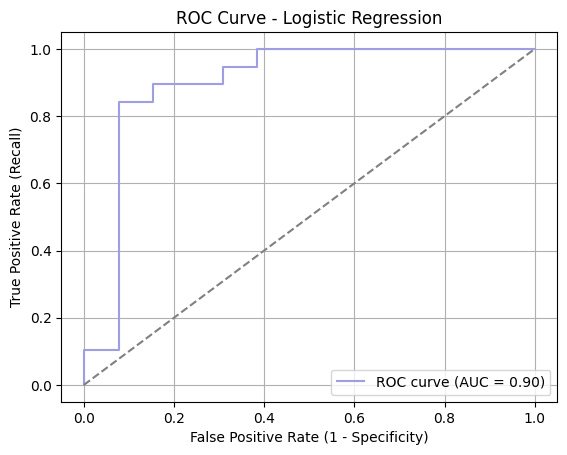

In [36]:
y_proba = model.predict_proba(X_test)[:, 1]
auc = np.round(roc_auc_score(y_test, y_proba),2)
print(f"AUC (modelo manual): {auc:.2f}")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})', color = '#9e9ee2')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid()
plt.show()

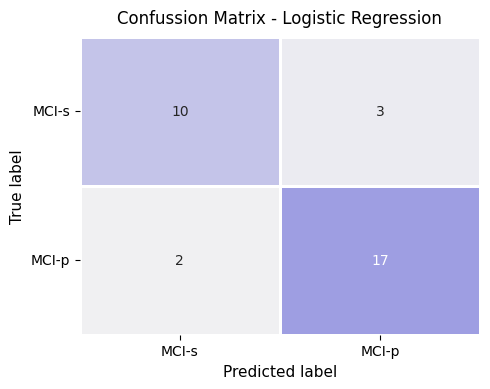

In [37]:
cm = confusion_matrix(y_test, y2, labels=[0, 1])
labels_cute = ['MCI-s', 'MCI-p']

plt.style.use('default')
fig, ax = plt.subplots(figsize=(5, 4))


sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=sns.light_palette("#9e9ee2", as_cmap=True),  # pastel verdoso
    cbar=False,
    linewidths=1,
    linecolor='white',
    xticklabels=labels_cute,
    yticklabels=labels_cute,
    ax=ax
)

ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.set_title("Confussion Matrix - Logistic Regression", fontsize=12, pad=10)

ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()


In [38]:
print(classification_report(y_test, y2, target_names=labels_cute))


results = pd.DataFrame(
    [['Logistic Regression', acc, prec, rec, f1, auc]],
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
)
print(results)

              precision    recall  f1-score   support

       MCI-s       0.83      0.77      0.80        13
       MCI-p       0.85      0.89      0.87        19

    accuracy                           0.84        32
   macro avg       0.84      0.83      0.84        32
weighted avg       0.84      0.84      0.84        32

                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression      0.84       0.85    0.89      0.87      0.9


#### SHAP

In [39]:
# Create explainer object
explainer = shap.LinearExplainer(model, X_train)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

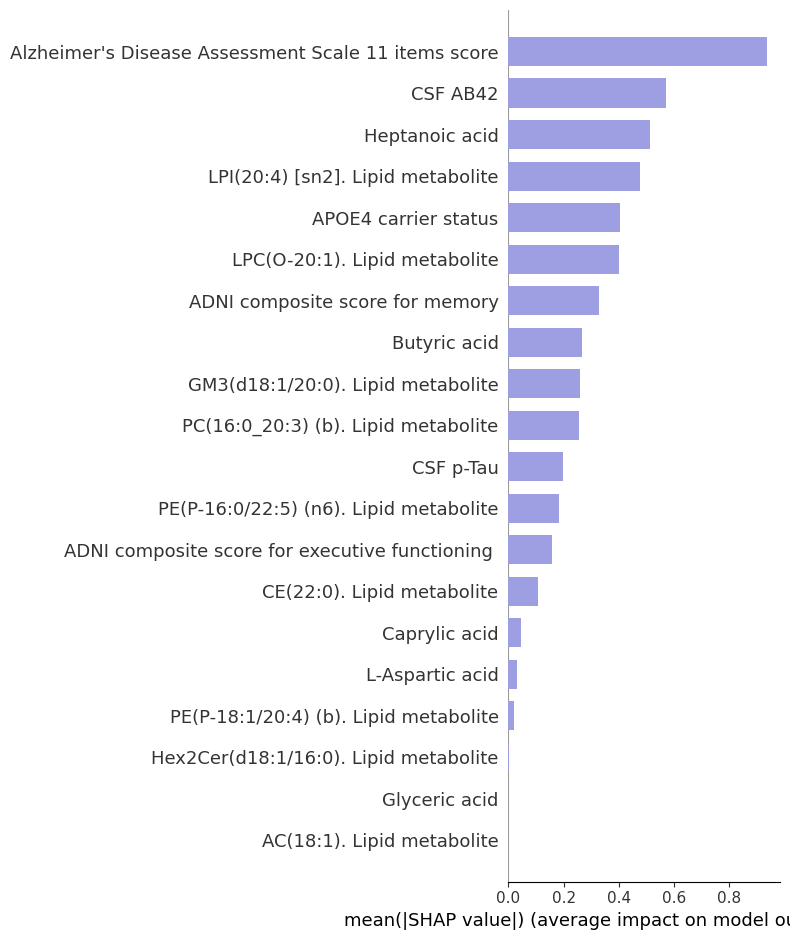

In [40]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    feature_names=X_test.columns.tolist(),
    show=False,
    color="#9e9ee2"
)

In [41]:
ruta_bar = "/content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/LRsummary_bar_feature_importance.tif"
os.makedirs(os.path.dirname(ruta_bar), exist_ok=True)

plt.close('all')

# Plot
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    feature_names=X_test.columns.tolist(),
    show=False,
    color="#9e9ee2"
)

# Customization
fig = plt.gcf()
ax = plt.gca()
fig.set_size_inches(18, 12)

# Grid
ax.grid(True, axis='x', linestyle='--', linewidth=0.5, alpha=0.5, color='gray')

# Title
plt.title("Logistic Regression SHAP Summary Plot", fontsize=14, fontweight='bold', pad=12)

# Saving
fig.savefig(ruta_bar, format="tiff", dpi=600, bbox_inches="tight")
plt.close(fig)

print("Bar plot guardado en:", ruta_bar)


Bar plot guardado en: /content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/LRsummary_bar_feature_importance.tif


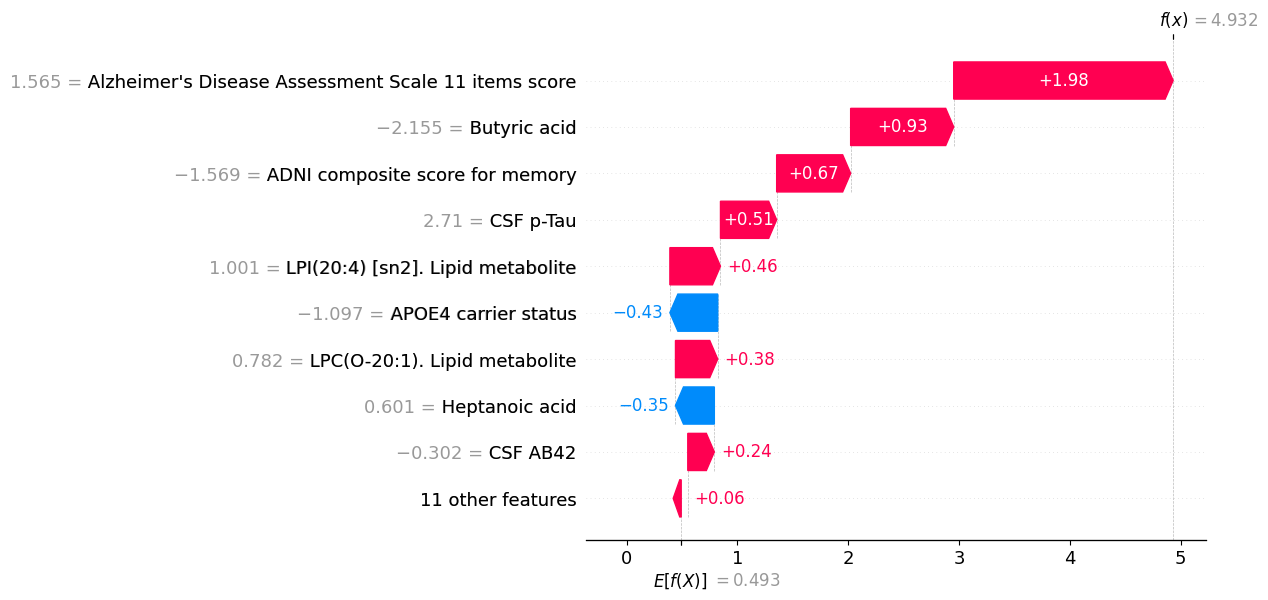

In [42]:
instance_index = 0
shap.waterfall_plot(shap.Explanation(values=shap_values[instance_index],
                                     base_values=explainer.expected_value,
                                     data=X_test.iloc[instance_index],
                                     feature_names=X_test.columns.tolist()))

In [43]:
ruta_bar = "/content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/LR_MCIp_class.tif"
os.makedirs(os.path.dirname(ruta_bar), exist_ok=True)

plt.close('all')

instance_index = 0
shap.waterfall_plot(shap.Explanation(values=shap_values[instance_index],
                                     base_values=explainer.expected_value,
                                     data=X_test.iloc[instance_index],
                                     feature_names=X_test.columns.tolist()),
                    show=False)
# Customization
fig = plt.gcf()
ax = plt.gca()
fig.set_size_inches(8, 8)

# Title
plt.title("LR Case of a patient classified as MCI-p", fontsize=14, fontweight='bold', pad=12)

# Saving
fig.savefig(ruta_bar, format="tiff", dpi=600, bbox_inches="tight")
plt.close(fig)

print("Bar plot guardado en:", ruta_bar)


Bar plot guardado en: /content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/LR_MCIp_class.tif


Índice con predicción negativa encontrado: 3


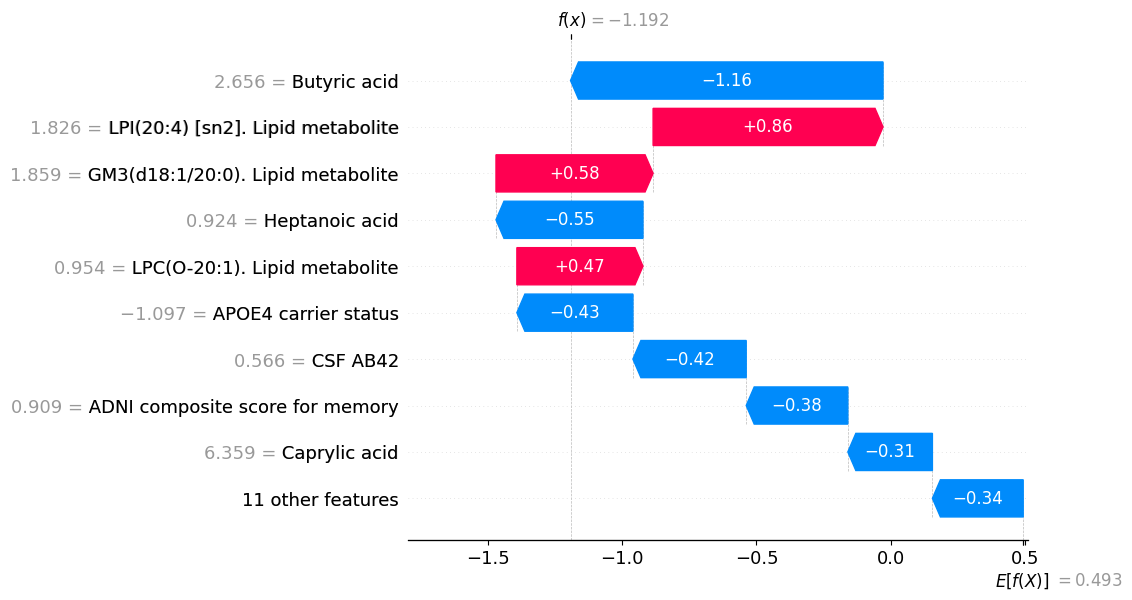

In [44]:
predicted_values = explainer.expected_value + shap_values.sum(axis=1)

# Find a negative prediction
negative_prediction_indices = [i for i, pred in enumerate(predicted_values) if pred < explainer.expected_value]

if negative_prediction_indices:
    instance_index = negative_prediction_indices[0]
    print(f"Índice con predicción negativa encontrado: {instance_index}")

    # Plot
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[instance_index],
            base_values=explainer.expected_value,
            data=X_test.iloc[instance_index],
            feature_names=X_test.columns.tolist()
        )
    )


In [45]:
ruta_bar = "/content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/LR_MCIs_class.tif"
os.makedirs(os.path.dirname(ruta_bar), exist_ok=True)

plt.close('all')

predicted_values = explainer.expected_value + shap_values.sum(axis=1)

negative_prediction_indices = [i for i, pred in enumerate(predicted_values) if pred < explainer.expected_value]

if negative_prediction_indices:
    instance_index = negative_prediction_indices[0]
    print(f"Índice con predicción negativa encontrado: {instance_index}")

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[instance_index],
            base_values=explainer.expected_value,
            data=X_test.iloc[instance_index],
            feature_names=X_test.columns.tolist()
        ),
        show = False
    )
# Customization
fig = plt.gcf()
ax = plt.gca()
fig.set_size_inches(8, 8)

# Title
plt.title("LR Case of a patient classified as MCI-s", fontsize=14, fontweight='bold', pad=12)

# Saving
fig.savefig(ruta_bar, format="tiff", dpi=600, bbox_inches="tight")
plt.close(fig)

print("Bar plot guardado en:", ruta_bar)

Índice con predicción negativa encontrado: 3
Bar plot guardado en: /content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/LR_MCIs_class.tif


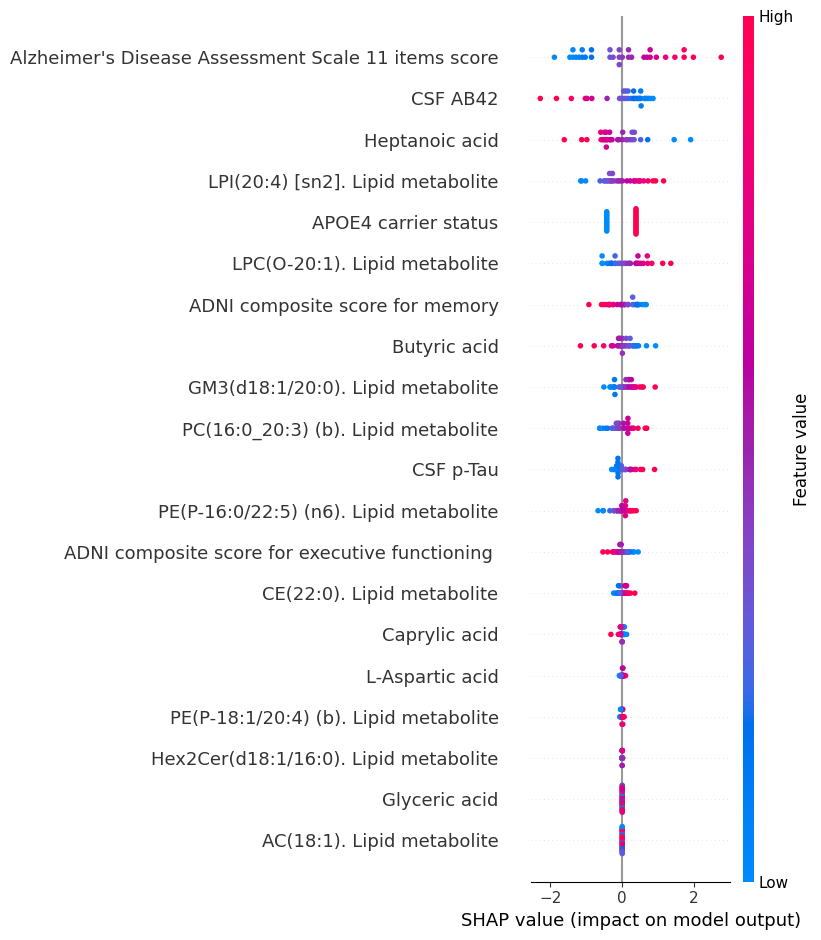

In [46]:

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns.tolist()
)

In [47]:
ruta_bar = "/content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/LRbeeswarm.tif"
os.makedirs(os.path.dirname(ruta_bar), exist_ok=True)

plt.close('all')

# Plot

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns.tolist(),
    show = False
)

# Customization
fig = plt.gcf()
ax = plt.gca()
fig.set_size_inches(18, 12)

# Title
plt.title("Logistic Regression Beeswarm Plot", fontsize=14, fontweight='bold', pad=12)

# Saving
fig.savefig(ruta_bar, format="tiff", dpi=600, bbox_inches="tight")
plt.close(fig)

print("Bar plot guardado en:", ruta_bar)

Bar plot guardado en: /content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/LRbeeswarm.tif


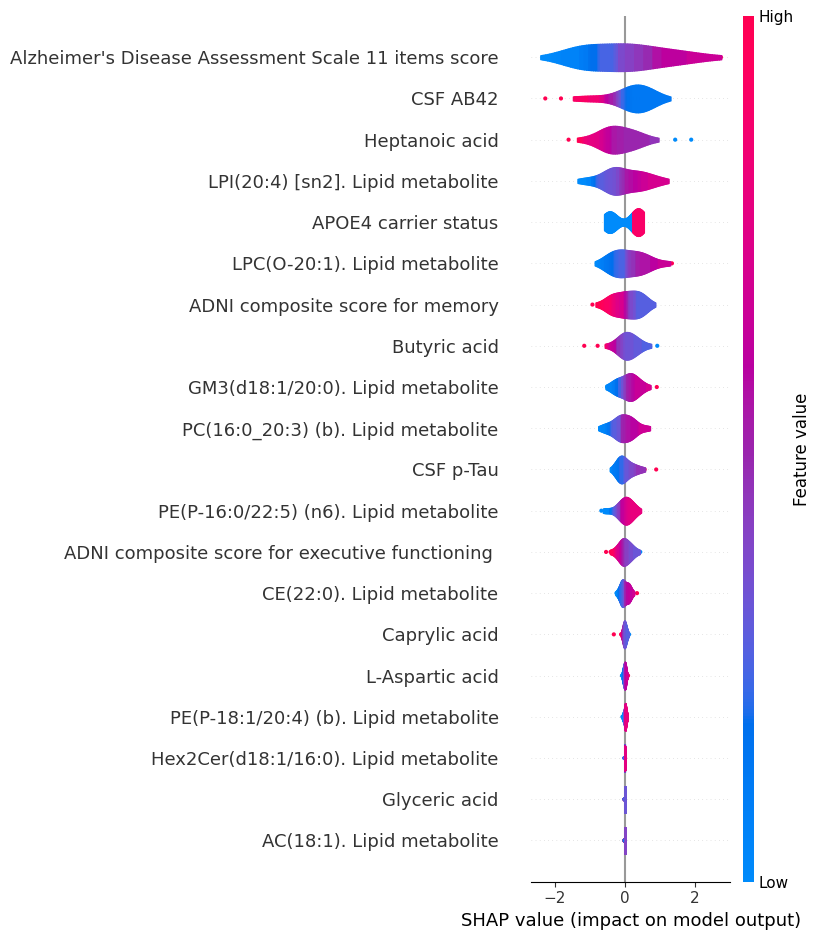

In [48]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="violin",
    feature_names=X_test.columns.tolist()
)

### XGB

In [49]:
def clean_colnames(df):
    df = df.copy()
    df.columns = (pd.Index(df.columns)
                    .map(str)                              # fuerza string
                    .str.replace(r'[\[\]<>]', '', regex=True) # quita [, ], <
                    .str.replace(r'\s+', '_', regex=True)  # espacios -> _
                    .str.replace(r'[^0-9a-zA-Z_]', '', regex=True))  # otros símbolos
    # por si quedaron duplicados, hazlos únicos
    if not df.columns.is_unique:
        df.columns = [f"f{i}" for i in range(len(df.columns))]
    return df

In [50]:
#X_train = clean_colnames(X_train)
#X_test  = X_test.copy()
#X_test.columns = X_train.columns

original_columns = X_train.columns.tolist()

X_train_clean = clean_colnames(X_train)
X_test_clean = clean_colnames(X_test)

mapping = dict(zip(X_train_clean.columns, original_columns))


In [51]:
X_train_clean

,ADNI_composite_score_for_memory,CSF_AB42,Alzheimers_Disease_Assessment_Scale_11_items_score,APOE4_carrier_status,LPCO201_Lipid_metabolite,ADNI_composite_score_for_executive_functioning_,LPI204_sn2_Lipid_metabolite,CSF_pTau,GM3d181200_Lipid_metabolite,Heptanoic_acid,PEP160225_n6_Lipid_metabolite,AC181_Lipid_metabolite,CE220_Lipid_metabolite,Caprylic_acid,Butyric_acid,Hex2Cerd181160_Lipid_metabolite,PC160_203_b_Lipid_metabolite,LAspartic_acid,PEP181204_b_Lipid_metabolite,Glyceric_acid
0,-1.992547,-0.904097,1.428974,0.911584,-0.315155,1.251211,-0.389211,-0.931226,0.449375,-3.824846,1.125780,-0.035076,0.095862,1.198059,-1.506930,-0.351766,0.944450,-0.430831,1.350684,-1.072305
1,0.138848,0.438794,-0.867368,-1.096991,0.654123,0.474794,2.215264,-0.918916,-0.674367,-1.739972,0.803506,-1.168031,-0.447339,1.110226,-0.949546,1.148643,0.274860,-0.216259,0.461894,-0.833430
2,-0.714543,-0.953934,0.820939,0.911584,0.164895,-0.232925,1.592392,2.191032,0.489816,-1.320679,1.043489,0.239793,1.068997,2.741322,-0.310025,-0.135477,0.830098,-1.691491,1.014289,-0.904233
3,-0.591044,-0.613514,0.889850,0.911584,1.214854,-1.374868,-0.064851,0.005913,0.124864,-1.222055,-0.399767,1.009121,0.700258,-0.492050,-1.427584,1.811667,-0.094845,0.316431,-0.137809,0.667079
4,-0.106762,-0.842637,-0.867368,0.911584,1.101210,1.725617,0.228060,-1.196672,1.307319,0.829874,0.733257,0.608745,1.403535,1.014592,-1.181305,1.283292,-0.790085,1.706226,0.379591,2.403899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,-1.359789,-0.374360,0.754056,0.911584,-0.817613,-0.203113,0.432373,0.171335,-0.337538,0.995876,1.751653,-0.198065,1.280971,0.176924,0.036837,1.292468,-0.673588,1.132926,-0.412748,-0.499261
126,-1.251554,0.230212,1.159412,0.911584,-1.391420,0.549973,1.063308,1.669373,-1.588979,-0.023323,-0.294641,-0.118489,0.634210,0.265186,-0.196310,-1.279989,0.796055,0.622831,1.966651,-0.502137
127,2.189761,2.755497,-1.475402,-1.096991,-1.509267,0.709404,0.641387,-0.894295,-0.286982,0.230090,-0.349125,0.022762,-0.546450,-0.187194,0.682432,-1.512407,1.023670,-0.515588,-0.641634,-1.166469
128,1.860893,-0.206539,-1.070046,-1.096991,-1.392529,1.273247,0.644005,-1.633696,0.436531,-0.444470,0.092539,-1.914172,0.484055,-0.350953,-0.010575,-0.973167,0.083201,1.329542,-0.394596,-0.601662


In [52]:
X_test_clean

,ADNI_composite_score_for_memory,CSF_AB42,Alzheimers_Disease_Assessment_Scale_11_items_score,APOE4_carrier_status,LPCO201_Lipid_metabolite,ADNI_composite_score_for_executive_functioning_,LPI204_sn2_Lipid_metabolite,CSF_pTau,GM3d181200_Lipid_metabolite,Heptanoic_acid,PEP160225_n6_Lipid_metabolite,AC181_Lipid_metabolite,CE220_Lipid_metabolite,Caprylic_acid,Butyric_acid,Hex2Cerd181160_Lipid_metabolite,PC160_203_b_Lipid_metabolite,LAspartic_acid,PEP181204_b_Lipid_metabolite,Glyceric_acid
0,-1.569321,-0.302073,1.564768,-1.096991,0.781769,-1.097483,1.001176,2.710382,-0.101013,0.601418,0.485242,-0.389099,-0.243923,0.000955,-2.154626,-1.928082,-0.655696,0.260094,0.661794,0.487746
1,-0.933788,-1.113794,-0.192451,-1.096991,-0.357864,0.076864,-0.669991,-0.760418,1.567160,0.491537,0.447190,0.663148,-0.178662,0.882768,-0.669841,0.238780,0.505038,-0.387733,0.290471,1.279638
2,-0.675689,-0.476582,0.618261,0.911584,1.182132,0.324436,2.437208,1.382384,0.883488,1.881000,-0.078005,1.147818,0.233351,0.086461,-0.227215,0.631836,0.063176,0.541667,0.528999,0.839886
3,0.908981,0.566173,0.212905,-1.096991,0.954258,0.559046,1.825829,-0.558833,1.859447,0.924429,-0.606255,3.166591,-0.345515,6.358624,2.655752,-0.306694,-0.925717,2.137928,-0.563527,1.339409
4,-1.030922,-0.677840,0.484494,0.911584,1.040962,0.292031,0.754321,-0.070259,-0.171877,2.676793,0.445004,0.912247,0.508280,-1.310437,0.064557,1.332276,0.083548,0.029424,0.713150,0.245344
5,0.063916,-1.025425,-1.003163,-1.096991,1.401976,0.131304,-0.242425,-1.087416,0.108130,-0.429485,-0.279694,0.668921,-0.820775,-1.307619,0.285996,0.077062,-1.513051,0.609396,-0.450561,0.626248
6,0.341442,-0.039195,-0.934252,0.911584,0.893003,0.775510,0.734912,0.116707,1.085237,-3.107270,0.045046,1.411827,-0.460786,0.150182,-1.567548,0.600242,0.456546,-0.331693,-0.284114,0.152936
7,1.196220,1.360699,-1.136930,-1.096991,0.480092,2.109289,1.978385,-0.621155,2.868951,-2.351359,1.486151,1.012848,1.173435,0.817266,-0.112616,0.553426,2.377607,0.492668,0.841895,-0.016628
8,1.376612,-0.664306,-0.664690,0.911584,0.870526,1.258989,0.062201,-0.571143,0.264709,0.564661,1.770704,-0.906843,0.809170,-0.531271,-0.273889,1.341399,0.494014,-0.839200,2.030832,-0.561048
9,-0.764497,-0.401747,0.551378,-1.096991,0.179587,-1.700211,-0.052261,1.096164,0.425867,0.163098,0.551331,-0.917962,-1.302947,-1.188914,-1.059396,-0.971357,-0.379576,0.889887,-0.136112,1.441494


#### Param Grid

In [53]:
param_grid = {
    "n_estimators": [150, 300, 500],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.5, 1.0],
    "reg_lambda": [1.0, 5.0, 10.0]
}

xgb = XGBClassifier(objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",   # rápido; si tienes GPU: 'gpu_hist'
    random_state=0,
    n_jobs=-1
)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

grid_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=100,
    scoring="f1_weighted",
    cv=skf,
    n_jobs=-1,
    random_state=0,
    refit=True,
    verbose=1
)


#### All Features Model

In [54]:
grid_search.fit(X_train_clean,y_train)
print ("Mean cross-validated score of the best_estimator: {}".format (grid_search.best_score_))
print ("best parameters: {}".format (grid_search.best_params_))
print ("best estimator: {}".format (grid_search.best_estimator_))

best = grid_search.best_estimator_
y1 = best.predict(X_test_clean)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Mean cross-validated score of the best_estimator: 0.8683444006973419
best parameters: {'subsample': 0.8, 'reg_lambda': 10.0, 'n_estimators': 150, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.8}
best estimator: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=0.5, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150,

In [55]:
model = XGBClassifier(subsample =0.8, reg_lambda=10.0, n_estimators=150,
                      min_child_weight = 3, max_depth = 3, learning_rate = 0.1,
                      gamma = 0.5, colsample_bytree=0.8, objective="binary:logistic",
                      eval_metric="auc",
                      tree_method="hist",   # rápido; si tienes GPU: 'gpu_hist'
                      random_state=0,
                      n_jobs=-1,).fit(X_train_clean,y_train)

y2 = model.predict(X_test_clean)
print(np.array_equal(y1, y2))  # True esperado

True


In [56]:
acc = np.round(accuracy_score(y_test, y2),2)
prec = np.round(precision_score(y_test, y2, pos_label=1),2)
rec = np.round(recall_score(y_test, y2, pos_label=1),2)
f1 = np.round(f1_score(y_test, y2, pos_label=1),2)

print("Accuracy", acc)
print("Precision", prec)
print("Recall", rec)
print("F1-score", f1)

Accuracy 0.84
Precision 0.82
Recall 0.95
F1-score 0.88


AUC (modelo manual): 0.91


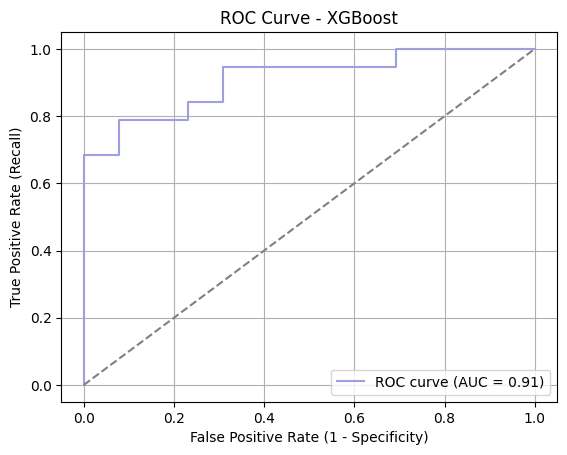

In [57]:
y_proba = model.predict_proba(X_test_clean)[:, 1]
auc = np.round(roc_auc_score(y_test, y_proba),2)
print(f"AUC (modelo manual): {auc:.2f}")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})', color = '#9e9ee2')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.grid()
plt.show()

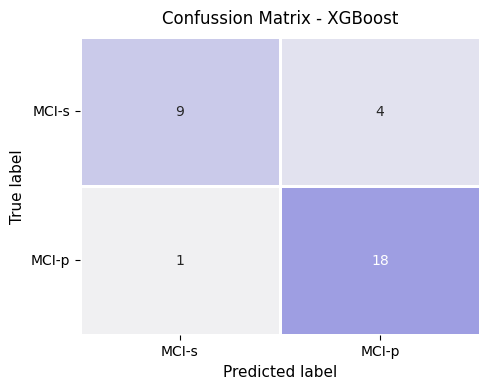

In [58]:
cm = confusion_matrix(y_test, y2, labels=[0, 1])
labels_cute = ['MCI-s', 'MCI-p']

plt.style.use('default')  # quitamos estilos raros
fig, ax = plt.subplots(figsize=(5, 4))

# paleta pastel tipo tus plots
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=sns.light_palette("#9e9ee2", as_cmap=True),  # pastel verdoso
    cbar=False,
    linewidths=1,
    linecolor='white',
    xticklabels=labels_cute,
    yticklabels=labels_cute,
    ax=ax
)

ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.set_title("Confussion Matrix - XGBoost", fontsize=12, pad=10)

# que se vean rectos
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()


In [59]:
print(classification_report(y_test, y2, target_names=labels_cute))


results = pd.DataFrame(
    [['XGB ALL Exp', acc, prec, rec, f1, auc]],
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
)
print(results)

              precision    recall  f1-score   support

       MCI-s       0.90      0.69      0.78        13
       MCI-p       0.82      0.95      0.88        19

    accuracy                           0.84        32
   macro avg       0.86      0.82      0.83        32
weighted avg       0.85      0.84      0.84        32

         Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  XGB ALL Exp      0.84       0.82    0.95      0.88     0.91


#### SHAP

In [60]:
import shap, xgboost
print("XGBoost:", xgboost.__version__)
print("SHAP:", shap.__version__)


XGBoost: 2.1.4
SHAP: 0.50.0


In [61]:
explainer = shap.TreeExplainer(model, X_train_clean)
shap_values = explainer.shap_values(X_test_clean)


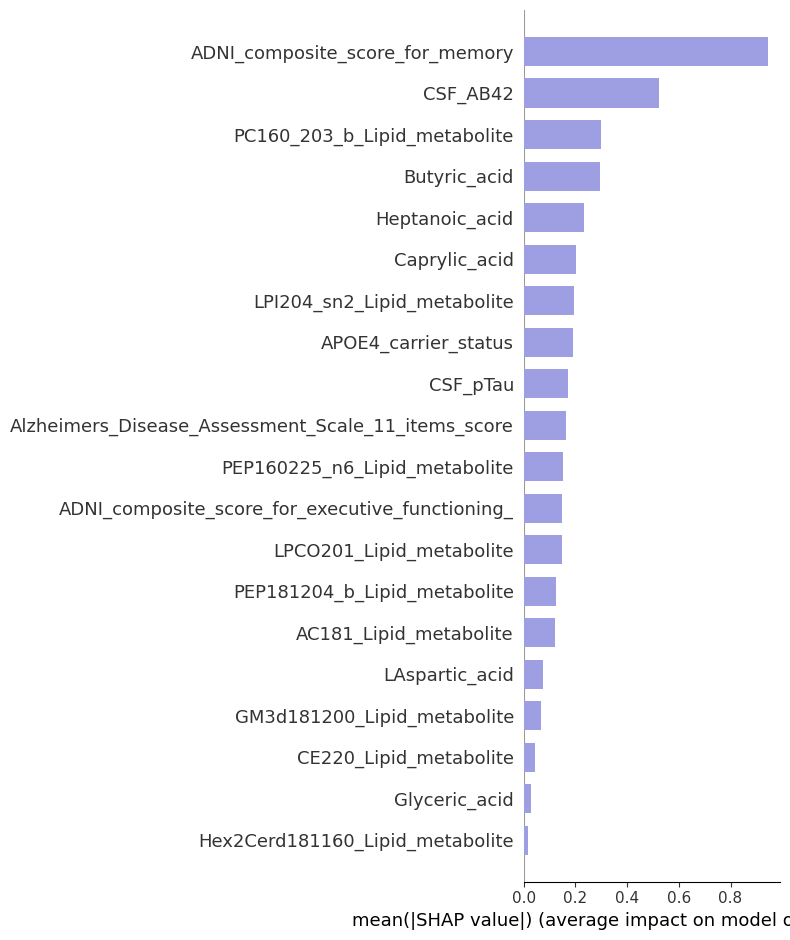

In [62]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    feature_names=X_test_clean.columns.tolist(),
    color="#9e9ee2"
)

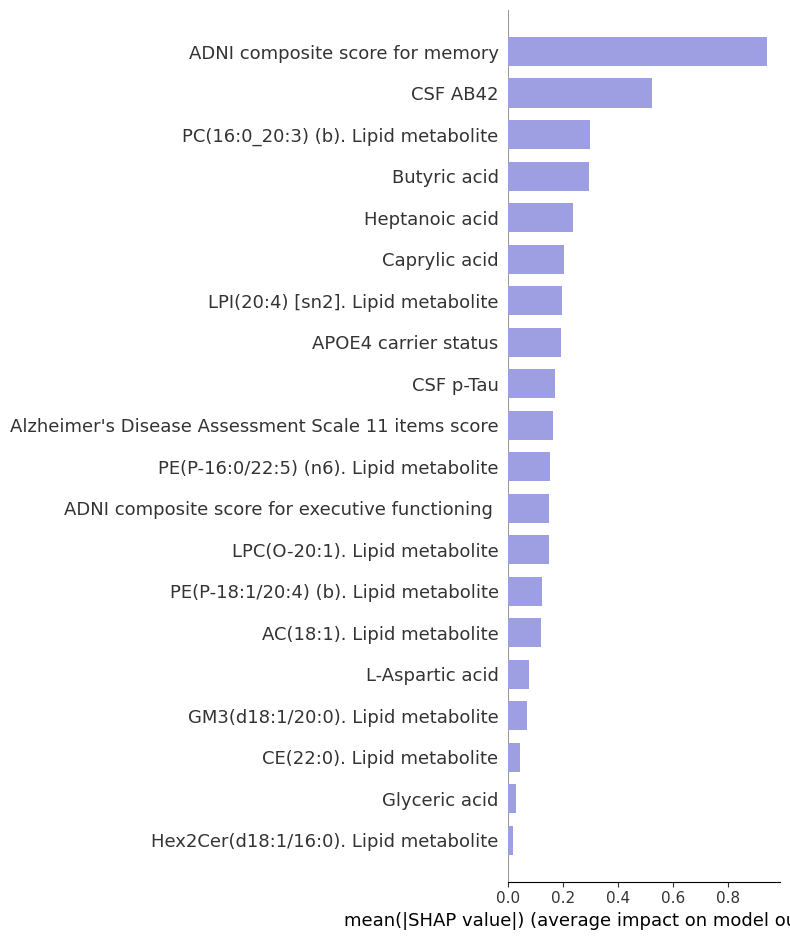

In [63]:
feature_names_original = [mapping.get(col, col) for col in X_test_clean.columns]
shap.summary_plot(
    shap_values,
    X_test_clean,
    plot_type="bar",
    feature_names=feature_names_original,
    color="#9e9ee2"
)


In [64]:
ruta_bar = "/content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/XGBsummary_bar_feature_importance.tif"
os.makedirs(os.path.dirname(ruta_bar), exist_ok=True)

plt.close('all')

# Plot
shap.summary_plot(
    shap_values,
    X_test_clean,
    plot_type="bar",
    feature_names=feature_names_original,
    show=False,
    color="#9e9ee2"
)


# Customization
fig = plt.gcf()
ax = plt.gca()
fig.set_size_inches(18, 12)

# Grid
ax.grid(True, axis='x', linestyle='--', linewidth=0.5, alpha=0.5, color='gray')

# Title
plt.title("XGBoost SHAP Summary Plot", fontsize=14, fontweight='bold', pad=12)

# Saving
fig.savefig(ruta_bar, format="tiff", dpi=600, bbox_inches="tight")
plt.close(fig)

print("Bar plot guardado en:", ruta_bar)


Bar plot guardado en: /content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/XGBsummary_bar_feature_importance.tif


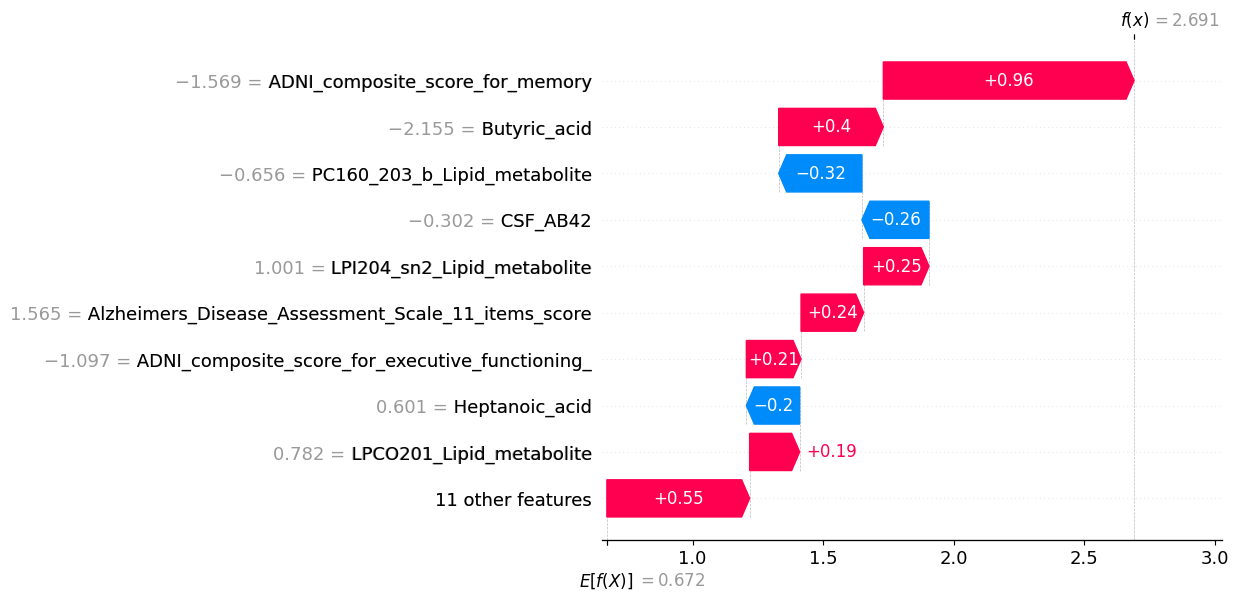

In [65]:
instance_index = 0
shap.waterfall_plot(shap.Explanation(values=shap_values[instance_index],
                                     base_values=explainer.expected_value,
                                     data=X_test_clean.iloc[instance_index],
                                     feature_names=X_test_clean.columns.tolist()))

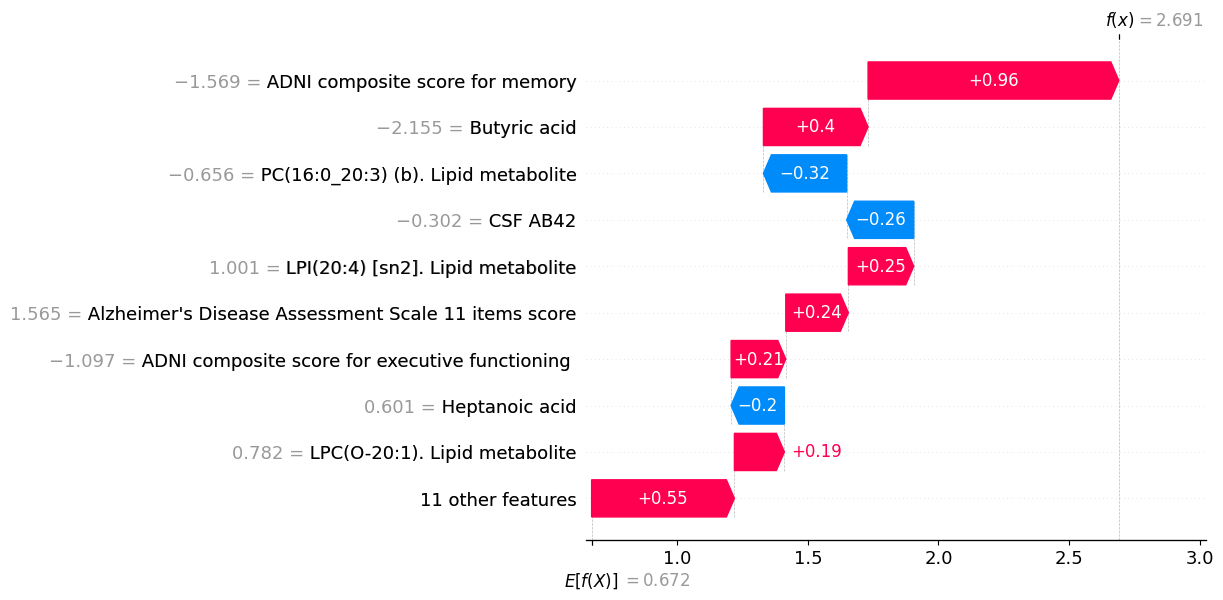

In [66]:
instance_index = 0
shap.waterfall_plot(shap.Explanation(values=shap_values[instance_index],
                                     base_values=explainer.expected_value,
                                     data=X_test_clean.iloc[instance_index],
                                     feature_names=feature_names_original))

In [67]:
ruta_bar = "/content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/XGB_MCIp_class.tif"
os.makedirs(os.path.dirname(ruta_bar), exist_ok=True)

plt.close('all')

instance_index = 0
shap.waterfall_plot(shap.Explanation(values=shap_values[instance_index],
                                     base_values=explainer.expected_value,
                                     data=X_test_clean.iloc[instance_index],
                                     feature_names=feature_names_original),
                    show = False)
# Customization
fig = plt.gcf()
ax = plt.gca()
fig.set_size_inches(8, 8)

# Title
plt.title("XGBoost Case of a patient classified as MCI-p", fontsize=14, fontweight='bold', pad=12)

# Saving
fig.savefig(ruta_bar, format="tiff", dpi=600, bbox_inches="tight")
plt.close(fig)



Índice con predicción negativa encontrado: 3


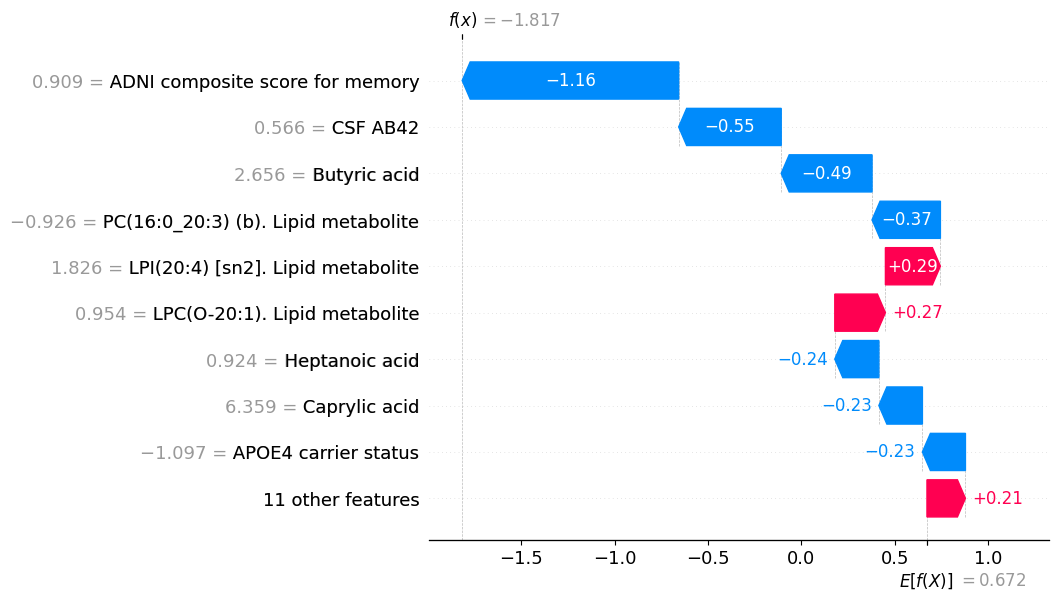

In [68]:
predicted_values = explainer.expected_value + shap_values.sum(axis=1)


negative_prediction_indices = [i for i, pred in enumerate(predicted_values) if pred < explainer.expected_value]

if negative_prediction_indices:
    instance_index = negative_prediction_indices[0]
    print(f"Índice con predicción negativa encontrado: {instance_index}")


    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[instance_index],
            base_values=explainer.expected_value,
            data=X_test_clean.iloc[instance_index],
            feature_names=feature_names_original
        )
    )


In [69]:
ruta_bar = "/content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/XGB_MCIs_class.tif"
os.makedirs(os.path.dirname(ruta_bar), exist_ok=True)

plt.close('all')

predicted_values = explainer.expected_value + shap_values.sum(axis=1)


negative_prediction_indices = [i for i, pred in enumerate(predicted_values) if pred < explainer.expected_value]

if negative_prediction_indices:
    instance_index = negative_prediction_indices[0]
    print(f"Índice con predicción negativa encontrado: {instance_index}")


    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[instance_index],
            base_values=explainer.expected_value,
            data=X_test_clean.iloc[instance_index],
            feature_names=feature_names_original
        ),
        show = False
    )

# Customization
fig = plt.gcf()
ax = plt.gca()
fig.set_size_inches(8, 8)

# Title
plt.title("XGBoost Case of a patient classified as MCI-s", fontsize=14, fontweight='bold', pad=12)

# Saving
fig.savefig(ruta_bar, format="tiff", dpi=600, bbox_inches="tight")
plt.close(fig)



Índice con predicción negativa encontrado: 3


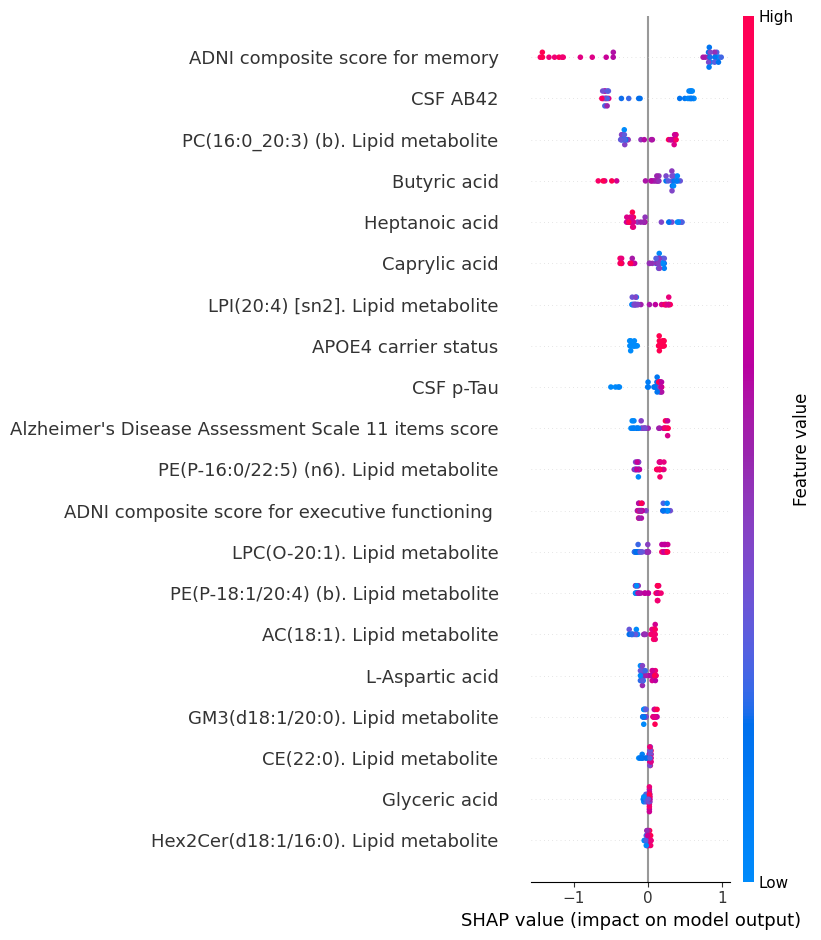

In [70]:
shap.summary_plot(
    shap_values,
    X_test_clean,
    feature_names=feature_names_original
)

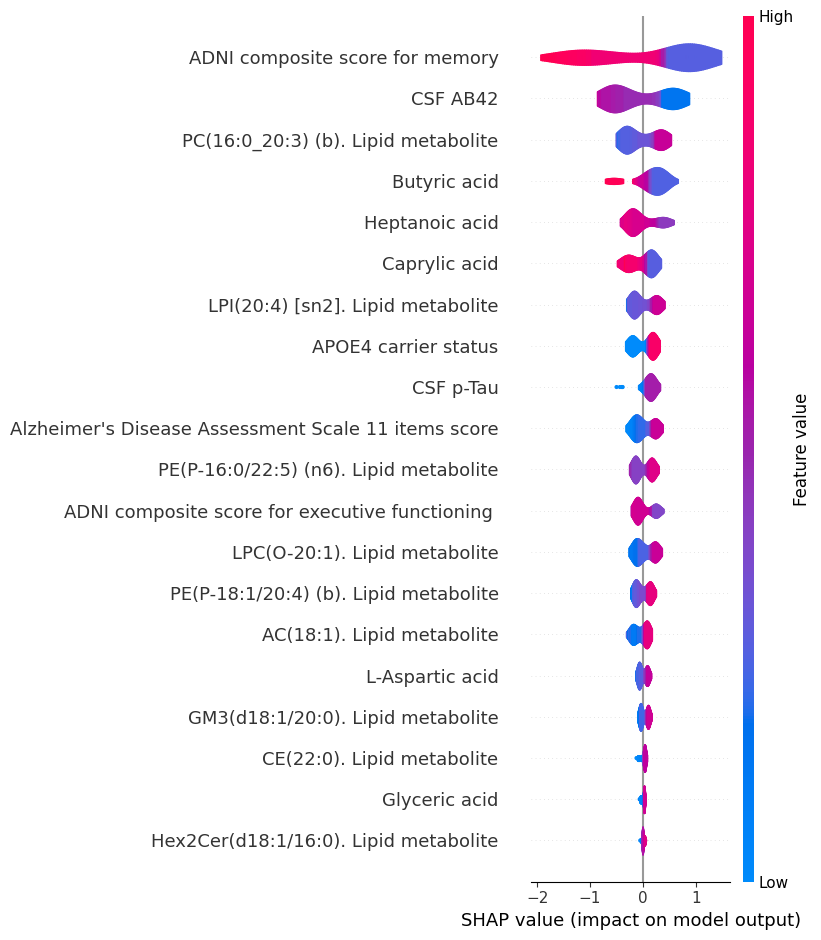

In [71]:
shap.summary_plot(
    shap_values,
    X_test_clean,
    plot_type="violin",
    feature_names=feature_names_original
)

In [72]:
ruta_bar = "/content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/XGBbeeswarm.tif"
os.makedirs(os.path.dirname(ruta_bar), exist_ok=True)

plt.close('all')

# Plot
shap.summary_plot(
    shap_values,
    X_test_clean,
    feature_names=feature_names_original,
    show = False
)

# Customization
fig = plt.gcf()
ax = plt.gca()
fig.set_size_inches(18, 12)

# Title
plt.title("XGBoost Beeswarm Plot", fontsize=14, fontweight='bold', pad=12)

# Saving
fig.savefig(ruta_bar, format="tiff", dpi=600, bbox_inches="tight")
plt.close(fig)

print("Bar plot guardado en:", ruta_bar)

Bar plot guardado en: /content/gdrive/MyDrive/Investigación Trejo-Castro/E31 - DBC Metabolic Health and Disease/E31.1 Alzheimer_GutMetabolites_Lipidomics/4. Results Plots/1. Exp MCI_to_AD/XGBbeeswarm.tif


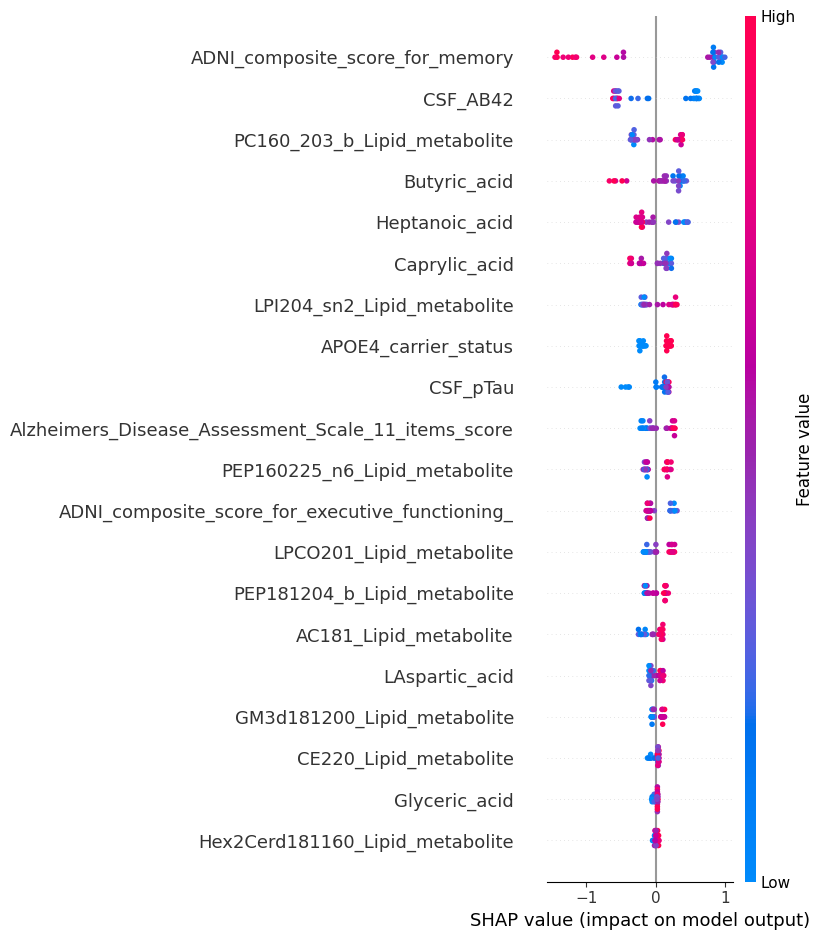

In [73]:
shap.summary_plot(
    shap_values,
    X_test_clean,
    feature_names=X_test_clean.columns.tolist()
)